In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

csv_files = sorted(DATA_DIR.glob("xApvaV01*.csv"))

tables = {}
for path in csv_files:
    name = path.stem.replace("xApvaV01", "")
    tables[name] = pd.read_csv(path)
    print(f"{name:45s} {tables[name].shape}")

list(tables.keys())

BirthQuality                                  (79, 9)
DurationBucketProbabilities                   (156, 7)
DurationBucketTransitions                     (156, 6)
EntryStats                                    (81, 8)
HazardRates                                   (487, 8)
IncubationQualityBucketProbabilities          (160, 7)
IncubationQualityBuckets                      (160, 6)
IncubationQualityConditionalProbabilities     (160, 8)
PersistenceStats                              (79, 6)
PrecursorStats                                (81, 17)
RunLengths                                    (38, 8)
SessionStats                                  (8, 13)
SponsorStates                                 (73, 6)
SponsorTransitions                            (279, 5)
StateLog_ES                                   (448, 20)
StateQuadrupletProbabilities                  (434, 7)
StateQuadruplets                              (434, 5)
StateTripletProbabilities                     (257, 7)
StateTriplets  

['BirthQuality',
 'DurationBucketProbabilities',
 'DurationBucketTransitions',
 'EntryStats',
 'HazardRates',
 'IncubationQualityBucketProbabilities',
 'IncubationQualityBuckets',
 'IncubationQualityConditionalProbabilities',
 'PersistenceStats',
 'PrecursorStats',
 'RunLengths',
 'SessionStats',
 'SponsorStates',
 'SponsorTransitions',
 'StateLog_ES',
 'StateQuadrupletProbabilities',
 'StateQuadruplets',
 'StateTripletProbabilities',
 'StateTriplets',
 'TransitionExpectancy',
 'TransitionProbabilities',
 'Transitions']

In [5]:
precursor = tables["PrecursorStats"]
expectancy = tables["TransitionExpectancy"]
birth = tables["BirthQuality"]
incub_cond = tables["IncubationQualityConditionalProbabilities"]

latest_bar = precursor["TotalBars"].max()

precursor_latest = precursor[precursor["TotalBars"] == latest_bar].copy()
expectancy_latest = expectancy[expectancy["TotalBars"] == latest_bar].copy()
birth_latest = birth[birth["TotalBars"] == latest_bar].copy()
incub_latest = incub_cond[incub_cond["TotalBars"] == latest_bar].copy()

latest_bar

np.int64(400)

In [6]:
cols = [
    "Transition",
    "Entries",
    "MeanPriorRunLength",
    "MeanIncubationQuality",
    "MeanStructuralCompression",
    "MeanEntropicCompression",
    "MeanExpansionPressure",
]

precursor_latest[cols].sort_values(
    "MeanIncubationQuality",
    ascending=False
)

,Transition,Entries,MeanPriorRunLength,MeanIncubationQuality,MeanStructuralCompression,MeanEntropicCompression,MeanExpansionPressure
70,Unresolved->Unknown,1,4.00,0.763,0.446,0.130,0.447
72,Directional->Degrading,10,2.70,0.741,0.466,0.333,0.612
79,Degrading->Directional,3,1.67,0.594,0.523,0.503,0.574
80,Directional->Unresolved,1,3.00,0.590,0.454,0.315,0.451
69,Unknown->Unresolved,2,3.00,0.541,0.458,0.214,0.297
74,Degrading->Balance,5,1.60,0.410,0.525,0.576,0.461
71,Unresolved->Directional,8,13.75,0.378,0.449,0.472,0.394
73,Degrading->Unresolved,17,2.06,0.367,0.457,0.573,0.479
75,Balance->Degrading,4,2.00,0.330,0.543,0.707,0.494
78,Unresolved->Degrading,11,7.27,0.267,0.465,0.612,0.408


In [7]:
precursor_latest.sort_values(
    "MeanIncubationQuality",
    ascending=False
)[
    [
        "Transition",
        "Entries",
        "MeanIncubationQuality",
        "MeanNextRunLength"
    ]
]

KeyError: "['MeanNextRunLength'] not in index"

In [10]:
merged = precursor_latest.merge(
    expectancy_latest[
        [
            "Transition",
            "MeanNextRunLength",
            "ImmediateFailurePct",
            "DirectionalContinuationPct"
        ]
    ],
    on="Transition",
    how="left"
)

merged.sort_values(
    "MeanIncubationQuality",
    ascending=False
)

,Instrument,SessionContext,TotalBars,Transition,Entries,MeanPriorRunLength,MeanSponsorConfidence,MaxSponsorConfidence,MeanDominanceScore,MeanDegradationScore,MeanBalanceScore,EventCount,MeanCompressionScore,MeanExpansionPressure,MeanStructuralCompression,MeanEntropicCompression,MeanIncubationQuality,MeanNextRunLength,ImmediateFailurePct,DirectionalContinuationPct
1,ES,RTH,400,Unresolved->Unknown,1,4.00,0.200,0.200,0.256,0.000,0.000,0,0.193,0.447,0.446,0.130,0.763,3.00,0.00,0.00
3,ES,RTH,400,Directional->Degrading,10,2.70,0.632,0.700,0.567,0.449,0.270,11,0.295,0.612,0.466,0.333,0.741,2.20,70.00,0.00
10,ES,RTH,400,Degrading->Directional,3,1.67,0.517,0.600,0.530,0.635,0.410,5,0.414,0.574,0.523,0.503,0.594,1.67,66.67,33.33
11,ES,RTH,400,Directional->Unresolved,1,3.00,0.350,0.550,0.395,0.327,0.249,0,0.330,0.451,0.454,0.315,0.590,2.00,0.00,0.00
0,ES,RTH,400,Unknown->Unresolved,2,3.00,0.250,0.250,0.122,0.066,0.074,4,0.352,0.297,0.458,0.214,0.541,20.50,0.00,0.00
5,ES,RTH,400,Degrading->Balance,5,1.60,0.602,0.700,0.410,0.718,0.506,8,0.460,0.461,0.525,0.576,0.410,1.00,100.00,0.00
2,ES,RTH,400,Unresolved->Directional,8,13.75,0.369,0.800,0.193,0.587,0.394,54,0.347,0.394,0.449,0.472,0.378,3.13,25.00,75.00
4,ES,RTH,400,Degrading->Unresolved,17,2.06,0.548,0.717,0.388,0.765,0.458,34,0.376,0.479,0.457,0.573,0.367,5.53,29.41,0.00
6,ES,RTH,400,Balance->Degrading,4,2.00,0.408,0.700,0.322,0.933,0.636,8,0.437,0.494,0.543,0.707,0.330,1.50,50.00,0.00
9,ES,RTH,400,Unresolved->Degrading,11,7.27,0.369,0.800,0.228,0.810,0.532,52,0.374,0.408,0.465,0.612,0.267,1.82,63.64,0.00


In [9]:
precursor_latest.sort_values(
    "MeanIncubationQuality",
    ascending=False
)[
    [
        "Transition",
        "Entries",
        "MeanIncubationQuality",
        "MeanNextRunLength"
    ]
]

KeyError: "['MeanNextRunLength'] not in index"

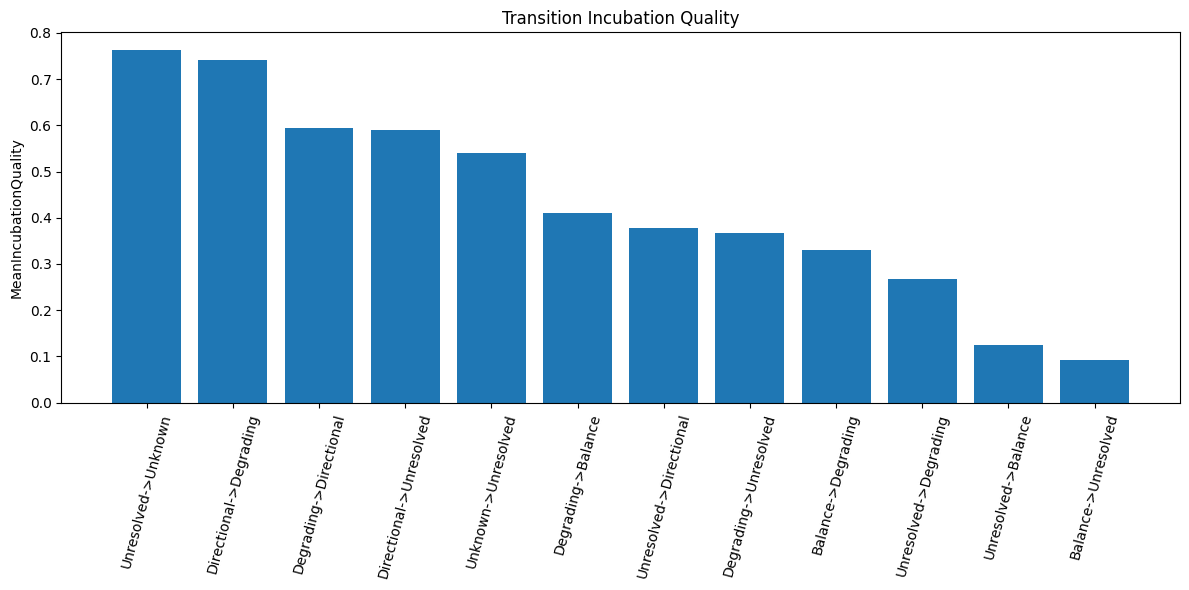

In [11]:
plt.figure(figsize=(12,6))

plot_df = merged.sort_values(
    "MeanIncubationQuality",
    ascending=False
)

plt.bar(
    plot_df["Transition"],
    plot_df["MeanIncubationQuality"]
)

plt.xticks(rotation=75)
plt.ylabel("MeanIncubationQuality")
plt.title("Transition Incubation Quality")

plt.tight_layout()
plt.show()

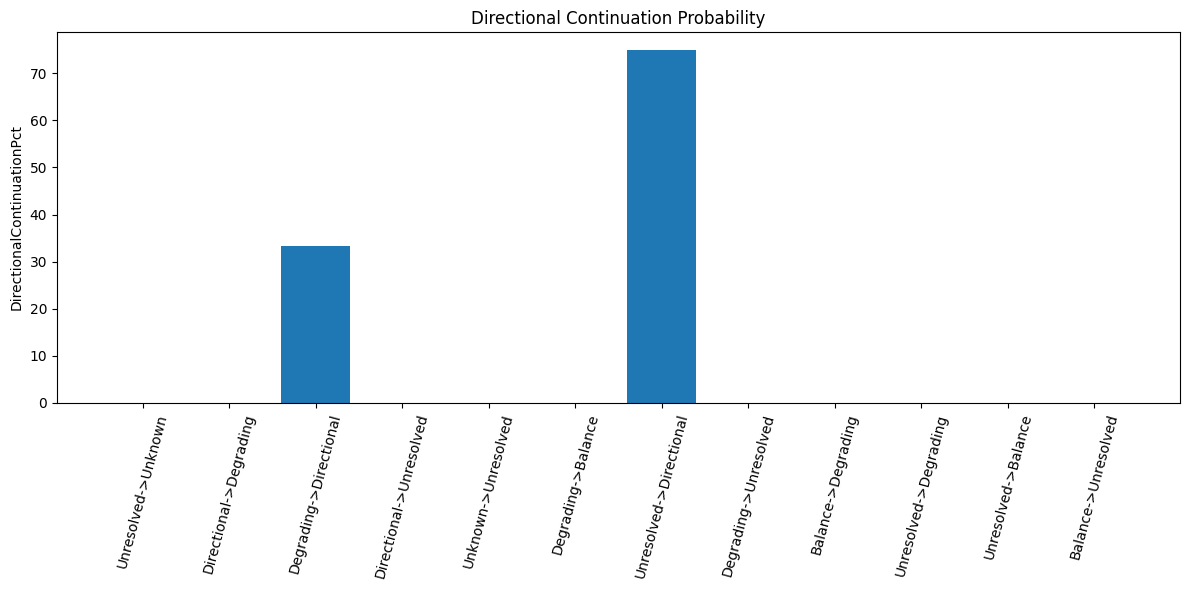

In [12]:
plt.figure(figsize=(12,6))

plt.bar(
    plot_df["Transition"],
    plot_df["DirectionalContinuationPct"].fillna(0)
)

plt.xticks(rotation=75)
plt.ylabel("DirectionalContinuationPct")
plt.title("Directional Continuation Probability")

plt.tight_layout()
plt.show()

In [13]:
merged[
    merged["Transition"].str.contains("Directional", na=False)
].sort_values(
    [
        "DirectionalContinuationPct",
        "MeanIncubationQuality"
    ],
    ascending=False
)

,Instrument,SessionContext,TotalBars,Transition,Entries,MeanPriorRunLength,MeanSponsorConfidence,MaxSponsorConfidence,MeanDominanceScore,MeanDegradationScore,MeanBalanceScore,EventCount,MeanCompressionScore,MeanExpansionPressure,MeanStructuralCompression,MeanEntropicCompression,MeanIncubationQuality,MeanNextRunLength,ImmediateFailurePct,DirectionalContinuationPct
2,ES,RTH,400,Unresolved->Directional,8,13.75,0.369,0.80,0.193,0.587,0.394,54,0.347,0.394,0.449,0.472,0.378,3.13,25.00,75.00
10,ES,RTH,400,Degrading->Directional,3,1.67,0.517,0.60,0.530,0.635,0.410,5,0.414,0.574,0.523,0.503,0.594,1.67,66.67,33.33
3,ES,RTH,400,Directional->Degrading,10,2.70,0.632,0.70,0.567,0.449,0.270,11,0.295,0.612,0.466,0.333,0.741,2.20,70.00,0.00
11,ES,RTH,400,Directional->Unresolved,1,3.00,0.350,0.55,0.395,0.327,0.249,0,0.330,0.451,0.454,0.315,0.590,2.00,0.00,0.00


In [14]:
merged.sort_values(
    "ImmediateFailurePct",
    ascending=False
)[
    [
        "Transition",
        "ImmediateFailurePct",
        "MeanNextRunLength",
        "MeanIncubationQuality"
    ]
]

,Transition,ImmediateFailurePct,MeanNextRunLength,MeanIncubationQuality
5,Degrading->Balance,100.00,1.00,0.410
3,Directional->Degrading,70.00,2.20,0.741
10,Degrading->Directional,66.67,1.67,0.594
9,Unresolved->Degrading,63.64,1.82,0.267
7,Unresolved->Balance,63.16,1.63,0.124
6,Balance->Degrading,50.00,1.50,0.330
4,Degrading->Unresolved,29.41,5.53,0.367
2,Unresolved->Directional,25.00,3.13,0.378
8,Balance->Unresolved,21.05,7.26,0.092
1,Unresolved->Unknown,0.00,3.00,0.763


In [15]:
numeric_cols = [
    "MeanPriorRunLength",
    "MeanIncubationQuality",
    "MeanStructuralCompression",
    "MeanEntropicCompression",
    "MeanExpansionPressure",
    "MeanNextRunLength",
    "ImmediateFailurePct",
    "DirectionalContinuationPct"
]

corr = merged[numeric_cols].corr()

corr

,MeanPriorRunLength,MeanIncubationQuality,MeanStructuralCompression,MeanEntropicCompression,MeanExpansionPressure,MeanNextRunLength,ImmediateFailurePct,DirectionalContinuationPct
MeanPriorRunLength,1.000000,-0.109841,-0.436849,-0.057384,-0.207656,-0.104399,-0.139856,0.754286
MeanIncubationQuality,-0.109841,1.000000,-0.150453,-0.860936,0.630183,0.035604,-0.199792,0.022434
MeanStructuralCompression,-0.436849,-0.150453,1.000000,0.514579,0.353374,-0.313619,0.641604,-0.075438
MeanEntropicCompression,-0.057384,-0.860936,0.514579,1.000000,-0.161155,-0.370209,0.546031,-0.008528
MeanExpansionPressure,-0.207656,0.630183,0.353374,-0.161155,1.000000,-0.520780,0.401345,0.063707
MeanNextRunLength,-0.104399,0.035604,-0.313619,-0.370209,-0.520780,1.000000,-0.526824,-0.125968
ImmediateFailurePct,-0.139856,-0.199792,0.641604,0.546031,0.401345,-0.526824,1.000000,-0.038266
DirectionalContinuationPct,0.754286,0.022434,-0.075438,-0.008528,0.063707,-0.125968,-0.038266,1.000000


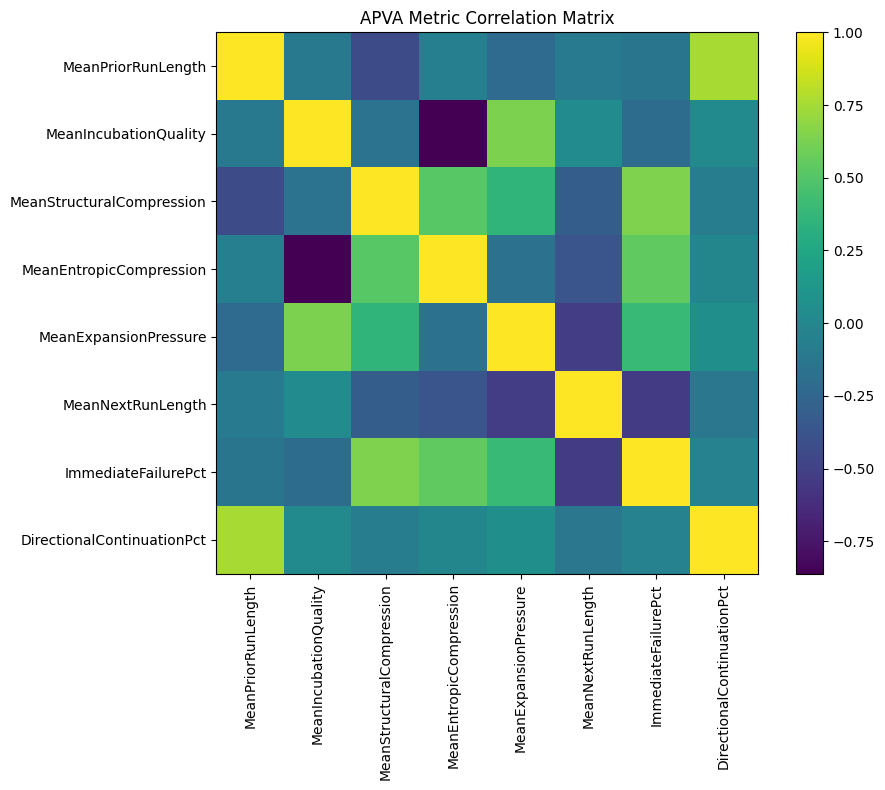

In [16]:
plt.figure(figsize=(10,8))

plt.imshow(corr, interpolation='nearest')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.title("APVA Metric Correlation Matrix")

plt.tight_layout()
plt.show()

In [17]:
# 1. Save merged master table
merged.to_csv("apva_merged_latest.csv", index=False)

# 2. Save top incubation-quality table
merged.sort_values(
    "MeanIncubationQuality",
    ascending=False
).to_csv("apva_top_incubation_quality.csv", index=False)

# 3. Save top directional-continuation table
merged.sort_values(
    "DirectionalContinuationPct",
    ascending=False
).to_csv("apva_top_directional_continuation.csv", index=False)

# 4. Save worst immediate-failure table
merged.sort_values(
    "ImmediateFailurePct",
    ascending=False
).to_csv("apva_worst_immediate_failure.csv", index=False)

# 5. Save correlation matrix
corr.to_csv("apva_correlation_matrix.csv")

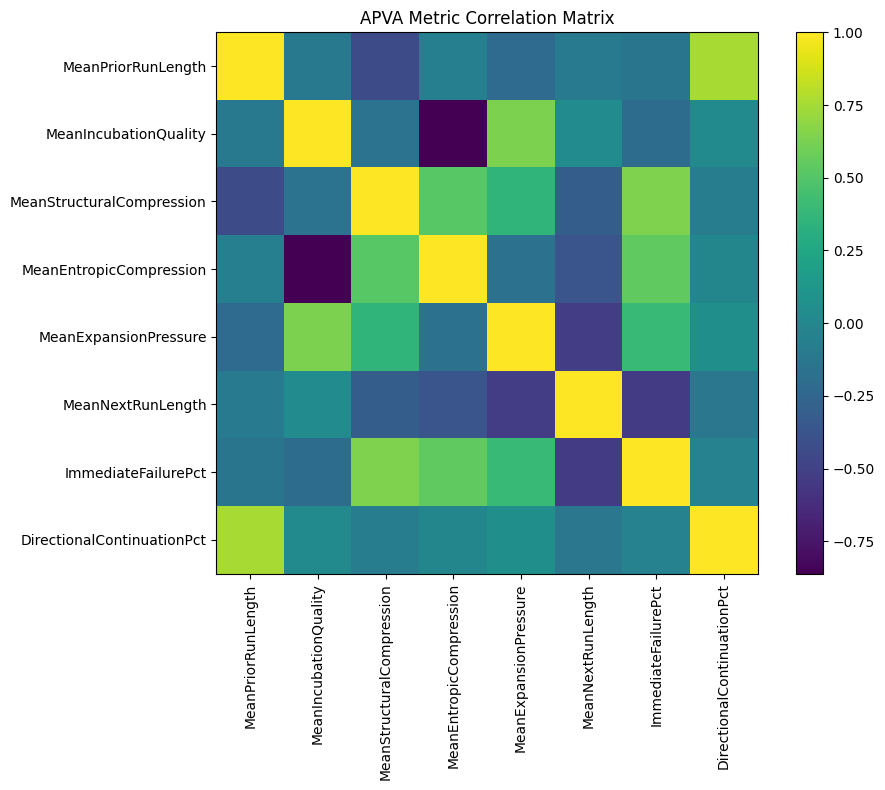

In [18]:
plt.figure(figsize=(10,8))
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("APVA Metric Correlation Matrix")
plt.tight_layout()
plt.savefig("apva_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()